# Кластеризация
### Задание.

В файле *biomedical_data_raw.csv* представлены биомедицинские данные пациентов.

Для каждого пациента измерены следующие показатели:  
- Возраст (аge)  
- Пол (gender)      
- Индекс массы тела (bmi)  
- Систолическое артериальное давление (sbp)  
- Уровень холестерина (cholesterol)  
- Группа крови (blood_type)  
- Уровень образования (education_level)  
- Стадия заболевания (disease_stage)  
- Курение (smoking)  
- Основной симптом заболевания (main_symptom)  
- Тип лечения (treatment)  

Выполните следующие задания на основе представленного датасета:

1) Проведите полный цикл предварительной обработки данных: определение типа переменных, поиск дубликатов, обработка пропущенных значений, обработка категориальных признаков, анализ выбросов, нормализация. Разделение на обучающую и тестовую выборки не требуется. Сопроводите свой анализ необходимыми графиками (боксплоты, столбчатые диаграммы). Все действия должны быть объяснены.

2) Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

3) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм кластеризации K-means. Число кластеров нужно выбрать так, чтобы по итогу между объектами из разных кластеров существовали статистически значимые отличия в значениях некоторых переменных. То есть на этом этапе необходимо также реализовать проверку статистических гипотез для сравнения переменных между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

4) Примените к исходным предобработанным данным (не PCA-трансформированным) функцию построения дендрограммы, используя разные методы оценки связи между кластерами. Какой метод позволяет получить более сбалансированные кластеры?

5) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

6) Сравните результаты K-means и агломеративной кластеризации. Насколько похожие кластеры были выделены этими алгоритмами?

7) Охарактеризуйте выделенные кластеры, определите их основные особенности (например, отличия по возрасту, полу и прочее).

3) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм кластеризации K-means. Число кластеров нужно выбрать так, чтобы по итогу между объектами из разных кластеров существовали статистически значимые отличия в значениях некоторых переменных. То есть на этом этапе необходимо также реализовать проверку статистических гипотез для сравнения переменных между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

In [21]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.stats import kruskal, chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style="whitegrid")

DATA_PATH = "biomedical_data_raw.csv"

1) Проведите полный цикл предварительной обработки данных: определение типа переменных, поиск дубликатов, обработка пропущенных значений, обработка категориальных признаков, анализ выбросов, нормализация. Разделение на обучающую и тестовую выборки не требуется. Сопроводите свой анализ необходимыми графиками (боксплоты, столбчатые диаграммы). Все действия должны быть объяснены.

In [22]:
# Загружаем данные

df_raw = pd.read_csv(DATA_PATH)
print("Размер датасета (строки, столбцы):", df_raw.shape)

df_raw.head()

Размер датасета (строки, столбцы): (612, 12)


,patient_id,age,gender,bmi,sbp,cholesterol,blood_type,education_level,disease_stage,smoking,main_symptom,treatment
0,PAT_0001,37,М,22.5,103.0,4.17,A,NaN,I,нет,слабость,консервативное
1,PAT_0002,34,М,22.7,106.0,4.68,B,NaN,II,NaN,слабость,NaN
2,PAT_0003,38,Ж,20.6,116.0,3.71,A,1.0,II,нет,температура,NaN
3,PAT_0004,42,Ж,22.5,115.0,4.45,O,2.0,I,нет,одышка,консервативное
4,PAT_0005,94,М,22.6,110.0,3.93,A,NaN,I,да,слабость,NaN


In [23]:
# 1) Предобработка данных
# Идея: привести данные к аккуратному виду, чтобы алгоритмы кластеризации работали корректно.
# Здесь делаем:
# - определяем числовые/категориальные признаки
# - чистим строки (пробелы, регистр)
# - проверяем дубликаты и пропуски

df = df_raw.copy()

# 1.1. Пустые строки считаем пропусками
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace({"": np.nan, " ": np.nan})

# 1.2. Аккуратно чистим текстовые категории: убираем лишние пробелы
text_cols = ["gender", "smoking", "main_symptom", "treatment", "blood_type", "disease_stage"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

# Приводим пол к единому виду (в данных встречается "м")
if "gender" in df.columns:
    df["gender"] = df["gender"].str.upper()

# Приводим симптом к единому регистру (встречается "Боль"/"боль")
if "main_symptom" in df.columns:
    df["main_symptom"] = df["main_symptom"].str.lower()

# 1.3. Явно задаём список числовых признаков
num_cols = ["age", "bmi", "sbp", "cholesterol", "education_level"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 1.4. Категориальные признаки — всё остальное, кроме идентификатора пациента
cat_cols = [c for c in df.columns if c not in num_cols + ["patient_id"]]

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

print("\nДубликаты строк:", int(df.duplicated().sum()))
print("Дубликаты patient_id:", int(df["patient_id"].duplicated().sum()))

# Доля пропусков по столбцам
missing_share = df.isna().mean().sort_values(ascending=False)
missing_share[missing_share > 0]

Числовые признаки: ['age', 'bmi', 'sbp', 'cholesterol', 'education_level']
Категориальные признаки: ['gender', 'blood_type', 'disease_stage', 'smoking', 'main_symptom', 'treatment']

Дубликаты строк: 12
Дубликаты patient_id: 12


education_level    0.781046
treatment          0.596405
bmi                0.058824
main_symptom       0.049020
smoking            0.040850
cholesterol        0.029412
dtype: float64

In [24]:
# Удалим полные дубликаты строк и дубликаты patient_id (оставляем первое наблюдение)

df = df.drop_duplicates().copy()
if "patient_id" in df.columns:
    df = df.drop_duplicates(subset=["patient_id"], keep="first").copy()

print("shape после удаления дубликатов:", df.shape)

# Некорректные значения возраста (age < 0) считаем ошибочными -> NaN
if "age" in df.columns:
    bad_age = (df["age"] < 0).sum()
    df.loc[df["age"] < 0, "age"] = np.nan
    print("Некорректный возраст (age < 0) заменён на NaN:", bad_age)

df.describe(include="all").T.head(15)

shape после удаления дубликатов: (600, 12)
Некорректный возраст (age < 0) заменён на NaN: 2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,600,600,PAT_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,598.0,NaN,NaN,NaN,48.804348,15.340693,18.0,36.0,48.0,60.0,99.0
gender,600,2,Ж,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,564.0,NaN,NaN,NaN,27.698637,6.113682,18.0,23.1,27.35,31.4,72.074534
sbp,600.0,NaN,NaN,NaN,134.865202,24.383733,82.0,117.0,133.0,147.0,299.85109
cholesterol,582.0,NaN,NaN,NaN,6.577042,2.118229,2.96,4.975,6.745,7.89,24.513367
blood_type,600,4,O,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,132.0,NaN,NaN,NaN,1.280303,0.7942,0.0,1.0,1.0,2.0,2.0
disease_stage,600,4,III,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking,576,2,нет,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN


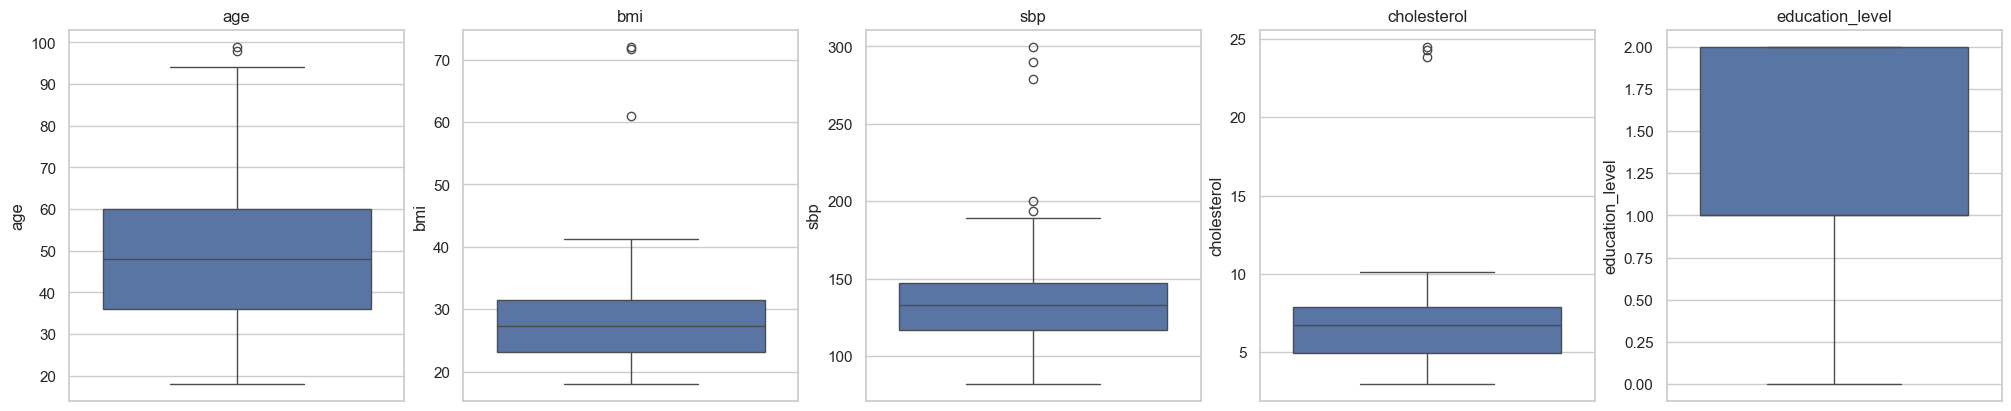

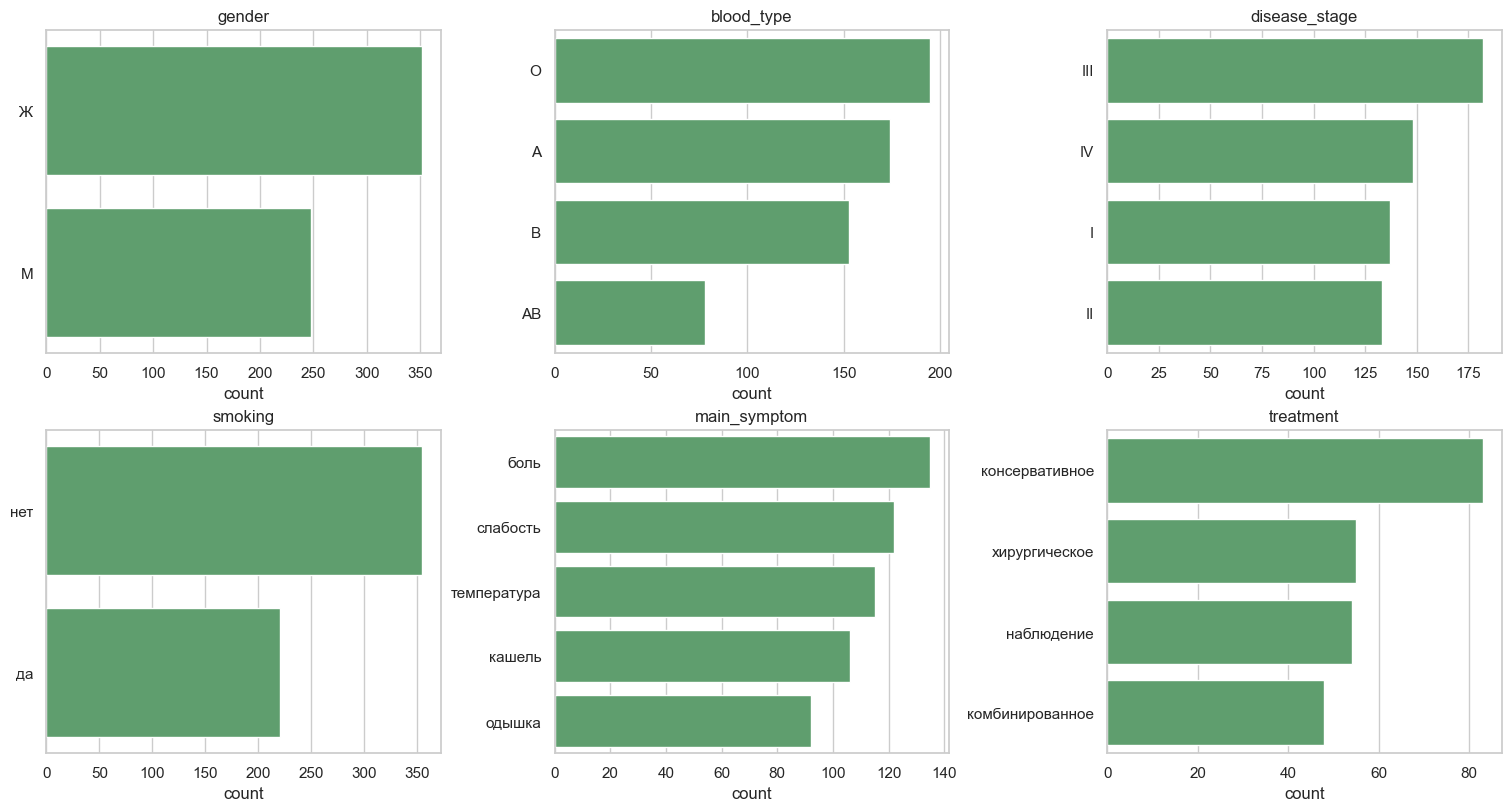

In [25]:
# Графики для первичного анализа: боксплоты для числовых, столбчатые диаграммы для категориальных

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4), constrained_layout=True)
if len(num_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.show()

# Категориальные распределения
n_cat = len(cat_cols)
cols = 3
rows = int(np.ceil(n_cat / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, c in enumerate(cat_cols):
    ax = axes[i]
    vc = df[c].value_counts(dropna=False).head(10)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="#55A868")
    ax.set_title(c)
    ax.set_xlabel("count")
    ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

In [26]:
# Обработка пропусков и выбросов.
# - Числовые: заполняем медианой.
# - Категориальные: заполняем модой (самым частым значением).
# - Выбросы: для числовых делаем клиппинг по правилу IQR (анализируем и ограничиваем влияние экстремумов).

df_clean = df.copy()

# Импутация (для дальнейших статистических тестов удобнее иметь заполненные значения)
for c in num_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    if c in df_clean.columns:
        mode = df_clean[c].mode(dropna=True)
        fill = mode.iloc[0] if len(mode) else "unknown"
        df_clean[c] = df_clean[c].fillna(fill)

# Клиппинг выбросов по IQR
clip_bounds = {}
for c in [c for c in num_cols if c in df_clean.columns]:
    q1 = df_clean[c].quantile(0.25)
    q3 = df_clean[c].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    clip_bounds[c] = (lo, hi)
    df_clean[c] = df_clean[c].clip(lo, hi)

clip_bounds

{'age': (np.float64(0.0), np.float64(96.0)),
 'bmi': (np.float64(11.2), np.float64(43.2)),
 'sbp': (np.float64(72.0), np.float64(192.0)),
 'cholesterol': (np.float64(1.0299999999999994), np.float64(11.99)),
 'education_level': (np.float64(1.0), np.float64(1.0))}

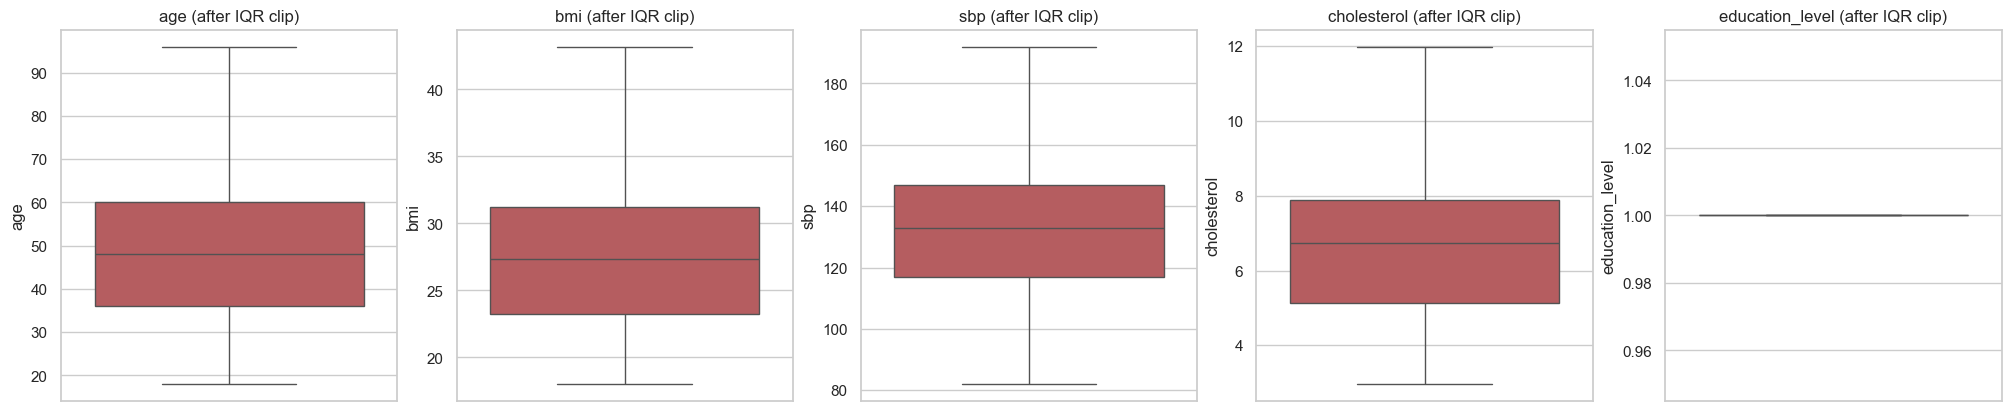

In [27]:
# Боксплоты после обработки выбросов (для сравнения)

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4), constrained_layout=True)
if len(num_cols) == 1:
    axes = [axes]
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_clean[c], ax=ax, color="#C44E52")
    ax.set_title(f"{c} (after IQR clip)")
plt.show()

In [28]:
# Кодирование категориальных признаков и нормализация для кластеризации.
# Чтобы K-means/агломеративная кластеризация могли работать:
# - категориальные признаки переводим в 0/1 (one-hot) через pandas.get_dummies
# - числовые нормализуем (StandardScaler), чтобы признаки были сопоставимы по масштабу

num_features = [c for c in num_cols if c in df_clean.columns]
cat_features = [c for c in cat_cols if c in df_clean.columns]

# 1) Числовые (после нашей импутации и клиппинга они уже без NaN)
X_num = df_clean[num_features].astype(float).to_numpy()
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# 2) Категориальные: one-hot
X_cat = pd.get_dummies(df_clean[cat_features], drop_first=False)

# 3) Итоговая матрица признаков для кластеризации
X = np.hstack([X_num_scaled, X_cat.to_numpy(dtype=float)])

print("Числовых признаков:", len(num_features))
print("One-hot признаков:", X_cat.shape[1])
print("Итоговая матрица X:", X.shape)

Числовых признаков: 5
One-hot признаков: 21
Итоговая матрица X: (600, 26)


2) Визуализируйте данные на плоскости применив метод главных компонент (PCA). На основе графика предположите, сколько кластеров существует в данных?

Доля объяснённой дисперсии (PC1, PC2): [0.3618 0.0964]


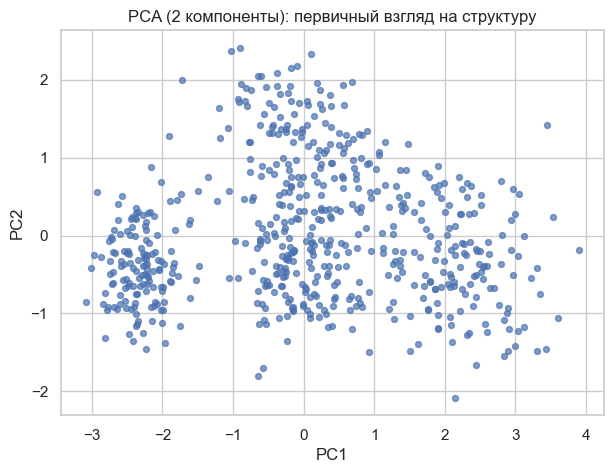

In [29]:
# 2) PCA-визуализация
# PCA не используется для самой кластеризации (по заданию),
# а только чтобы "увидеть" данные на плоскости.

pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X)

print("Доля объяснённой дисперсии (PC1, PC2):", np.round(pca2.explained_variance_ratio_, 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18, alpha=0.7)
plt.title("PCA (2 компоненты): первичный взгляд на структуру")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [30]:
# 3) K-means + проверка гипотез между кластерами
# Для числовых признаков: тест Краскела–Уоллиса.
# Для категориальных: хи-квадрат по таблице сопряжённости.

def cluster_significance_tests(df_for_tests: pd.DataFrame, labels: np.ndarray, alpha: float = 0.05):
    out_rows = []
    tmp = df_for_tests.copy()
    tmp["cluster"] = labels

    # числовые
    for c in num_features:
        groups = [g[c].values for _, g in tmp.groupby("cluster")]
        stat, p = kruskal(*groups)
        out_rows.append({"feature": c, "type": "numeric", "p_value": p})

    # категориальные
    for c in cat_features:
        ct = pd.crosstab(tmp["cluster"], tmp[c])
        chi2, p, dof, exp = chi2_contingency(ct)
        out_rows.append({"feature": c, "type": "categorical", "p_value": p})

    res = pd.DataFrame(out_rows).sort_values("p_value")
    res["significant"] = res["p_value"] < alpha
    return res

k_candidates = range(2, 7)
rows = []

for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    tests = cluster_significance_tests(df_clean[num_features + cat_features], labels)
    n_sig = int(tests["significant"].sum())
    sizes = pd.Series(labels).value_counts().sort_index().to_list()

    rows.append({
        "k": k,
        "silhouette": sil,
        "n_significant_features_(p<0.05)": n_sig,
        "cluster_sizes": sizes,
    })

summary_km = pd.DataFrame(rows).sort_values(["n_significant_features_(p<0.05)", "silhouette"], ascending=False)
summary_km

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


,k,silhouette,n_significant_features_(p<0.05),cluster_sizes
1,3,0.174716,10,"[162, 290, 148]"
2,4,0.159804,10,"[139, 146, 160, 155]"
3,5,0.159714,10,"[148, 145, 82, 163, 62]"
4,6,0.143291,10,"[66, 92, 145, 73, 83, 141]"
0,2,0.193620,8,"[298, 302]"


In [31]:
# Выберем k с максимальным числом значимых различий (и без слишком маленьких кластеров)

def min_cluster_size(sizes):
    return int(np.min(sizes)) if len(sizes) else 0

summary_km["min_cluster"] = summary_km["cluster_sizes"].apply(min_cluster_size)
summary_km_sorted = summary_km.sort_values(
    ["n_significant_features_(p<0.05)", "min_cluster", "silhouette"],
    ascending=False,
)
summary_km_sorted

,k,silhouette,n_significant_features_(p<0.05),cluster_sizes,min_cluster
1,3,0.174716,10,"[162, 290, 148]",148
2,4,0.159804,10,"[139, 146, 160, 155]",139
4,6,0.143291,10,"[66, 92, 145, 73, 83, 141]",66
3,5,0.159714,10,"[148, 145, 82, 163, 62]",62
0,2,0.193620,8,"[298, 302]",298


In [32]:
k_opt = int(summary_km_sorted.iloc[0]["k"])
print("Выбранное k для K-means:", k_opt)

kmeans = KMeans(n_clusters=k_opt, n_init=20, random_state=42)
labels_km = kmeans.fit_predict(X)

tests_km = cluster_significance_tests(df_clean[num_features + cat_features], labels_km)
tests_km.head(15)

Выбранное k для K-means: 3


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


,feature,type,p_value,significant
2,sbp,numeric,1.434842e-88,True
0,age,numeric,4.573320e-80,True
1,bmi,numeric,4.959530e-77,True
3,cholesterol,numeric,4.784127e-75,True
7,disease_stage,categorical,3.693328e-73,True
9,main_symptom,categorical,7.048068e-39,True
10,treatment,categorical,7.208318e-08,True
8,smoking,categorical,5.135359e-04,True
6,blood_type,categorical,3.624608e-03,True
5,gender,categorical,4.326292e-03,True


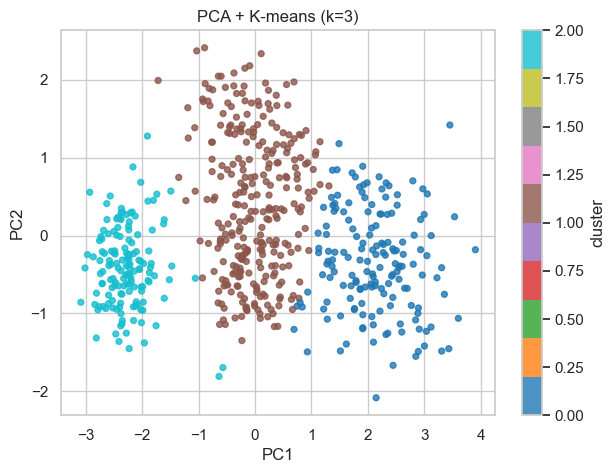

In [33]:
# PCA-проекция с цветами кластеров K-means

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap="tab10", s=18, alpha=0.8)
plt.title(f"PCA + K-means (k={k_opt})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.show()

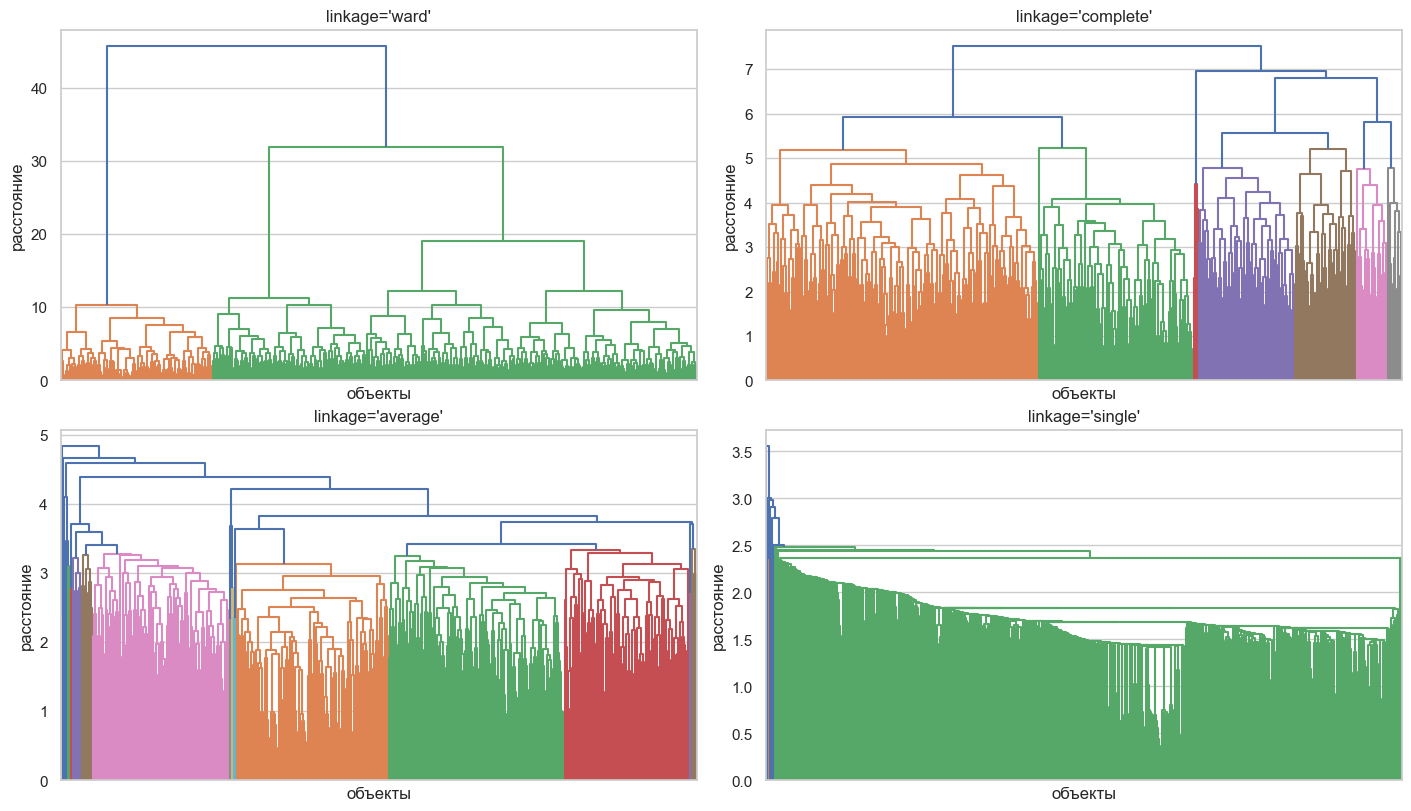

,method,cluster_sizes,min_cluster,max_cluster,max/min
0,ward,"[143, 145, 312]",143,312,2.181818
1,complete,"[404, 4, 192]",4,404,101.000000
2,average,"[2, 597, 1]",1,597,597.000000
3,single,"[598, 1, 1]",1,598,598.000000


In [34]:
# 4) Дендрограммы разными методами связи
# Дальше используем иерархическую кластеризацию (дендрограммы),
# поэтому сравним несколько способов "связи" (linkage).
#
# Про "сбалансированность":
# - грубая, но понятная оценка: если разрезать дендрограмму на k кластеров,
#   то чем ближе размеры кластеров друг к другу, тем "сбалансированнее" разбиение.

methods = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

linkages = {}
for ax, m in zip(axes, methods):
    Z = linkage(X, method=m)
    linkages[m] = Z
    dendrogram(Z, no_labels=True, ax=ax)
    ax.set_title(f"linkage='{m}'")
    ax.set_xlabel("объекты")
    ax.set_ylabel("расстояние")

plt.show()

# Сравним баланс кластеров при разрезе на k_opt (k выбрали в K-means)
balance_rows = []
for m in methods:
    cl = fcluster(linkages[m], t=k_opt, criterion="maxclust")
    sizes = pd.Series(cl).value_counts().sort_index()
    balance_rows.append({
        "method": m,
        "cluster_sizes": sizes.to_list(),
        "min_cluster": int(sizes.min()),
        "max_cluster": int(sizes.max()),
        "max/min": float(sizes.max() / sizes.min()),
    })

balance = pd.DataFrame(balance_rows).sort_values("max/min")
balance

5) Примените к исходным предобработанным данным (не PCA-трансформированным) алгоритм агломеративной кластеризации с выбранным на предыдущем шаге методом оценки связи. Выберите оптимальное число кластеров на основе анализа дендрограммы и статистических различией между кластерами. После выбора окончательного числа кластеров визуализируйте данные на плоскости, применив PCA и изобразив точки разными цветами в зависимости от номера кластера.

In [35]:
best_linkage = balance.iloc[0]["method"]
print("Выбранный (наиболее сбалансированный) linkage:", best_linkage)

# 5) Агломеративная кластеризация с выбранным linkage.
# По заданию кластеризацию делаем на X (не PCA),
# а число кластеров подбираем, чтобы были статистически значимые различия.

def agglom_labels_for_k(k: int, linkage_method: str):
    # В AgglomerativeClustering мы задаём число кластеров напрямую.
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage_method, metric="euclidean")
    return model.fit_predict(X)

rows = []
for k in range(2, 7):
    labels = agglom_labels_for_k(k, best_linkage)

    # Silhouette — вспомогательная метрика качества кластеризации
    sil = silhouette_score(X, labels)

    # Главное по заданию — проверка статистических различий между кластерами
    tests = cluster_significance_tests(df_clean[num_features + cat_features], labels)
    n_sig = int(tests["significant"].sum())

    sizes = pd.Series(labels).value_counts().sort_index().to_list()
    rows.append({
        "k": k,
        "silhouette": sil,
        "n_significant_features_(p<0.05)": n_sig,
        "cluster_sizes": sizes,
    })

summary_ag = pd.DataFrame(rows).sort_values(
    ["n_significant_features_(p<0.05)", "silhouette"],
    ascending=False,
)
summary_ag

Выбранный (наиболее сбалансированный) linkage: ward


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


,k,silhouette,n_significant_features_(p<0.05),cluster_sizes
4,6,0.121178,10,"[145, 143, 89, 108, 63, 52]"
3,5,0.119700,10,"[141, 143, 145, 108, 63]"
0,2,0.212292,9,"[457, 143]"
1,3,0.167116,9,"[312, 143, 145]"
2,4,0.148412,9,"[171, 141, 145, 143]"


In [36]:
summary_ag["min_cluster"] = summary_ag["cluster_sizes"].apply(min_cluster_size)
summary_ag_sorted = summary_ag.sort_values(
    ["n_significant_features_(p<0.05)", "min_cluster", "silhouette"],
    ascending=False,
)
summary_ag_sorted

,k,silhouette,n_significant_features_(p<0.05),cluster_sizes,min_cluster
3,5,0.119700,10,"[141, 143, 145, 108, 63]",63
4,6,0.121178,10,"[145, 143, 89, 108, 63, 52]",52
0,2,0.212292,9,"[457, 143]",143
1,3,0.167116,9,"[312, 143, 145]",143
2,4,0.148412,9,"[171, 141, 145, 143]",141


In [37]:
k_opt_ag = int(summary_ag_sorted.iloc[0]["k"])
print("Выбранное k для агломеративной кластеризации:", k_opt_ag)

labels_ag = agglom_labels_for_k(k_opt_ag, best_linkage)

tests_ag = cluster_significance_tests(df_clean[num_features + cat_features], labels_ag)
tests_ag.head(15)

Выбранное k для агломеративной кластеризации: 5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_stats_py.py:8492: RuntimeWarning: divide by zero encountered in scalar divide
  h /= ties


,feature,type,p_value,significant
7,disease_stage,categorical,1.093036e-123,True
3,cholesterol,numeric,5.683052e-93,True
2,sbp,numeric,1.450110e-83,True
0,age,numeric,4.413428e-78,True
1,bmi,numeric,1.840510e-72,True
9,main_symptom,categorical,4.529743e-38,True
5,gender,categorical,4.375521e-31,True
10,treatment,categorical,8.941256e-06,True
8,smoking,categorical,2.339498e-05,True
6,blood_type,categorical,8.782406e-04,True


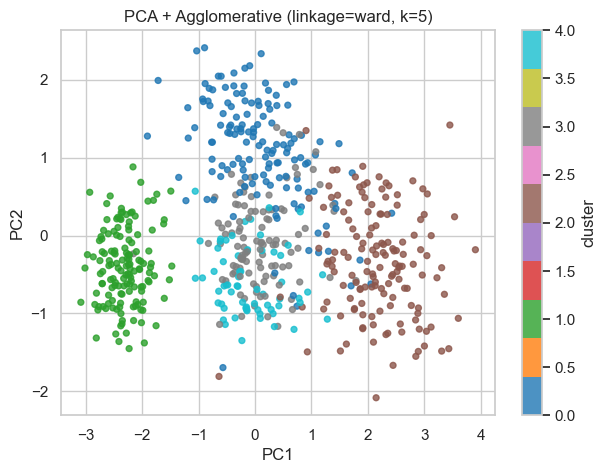

In [38]:
# PCA-проекция с цветами кластеров Agglomerative

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ag, cmap="tab10", s=18, alpha=0.8)
plt.title(f"PCA + Agglomerative (linkage={best_linkage}, k={k_opt_ag})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.show()

In [39]:
# 6) Сравнение K-means и агломеративной кластеризации
# Используем Adjusted Rand Index (ARI): 1 — полностью совпадают, 0 — случайное совпадение.

# Если k отличаются, сравним при общем k = k_opt (как в K-means) и при k_opt_ag.

ari_same_k = None
if k_opt_ag == k_opt:
    ari_same_k = adjusted_rand_score(labels_km, labels_ag)
    print("ARI (при одинаковом k):", ari_same_k)
else:
    labels_ag_kmK = agglom_labels_for_k(k_opt, best_linkage)
    ari_same_k = adjusted_rand_score(labels_km, labels_ag_kmK)
    print(f"k различаются (K-means k={k_opt}, Agg k={k_opt_ag}).")
    print("ARI (Agglomerative пересчитан при k=", k_opt, "):", ari_same_k)

# 7) Характеристика кластеров (по итоговым меткам K-means)

df_profile = df_clean.copy()
df_profile["cluster_kmeans"] = labels_km

num_profile = df_profile.groupby("cluster_kmeans")[num_features].agg(["count", "mean", "median"]).round(3)
num_profile

k различаются (K-means k=3, Agg k=5).
ARI (Agglomerative пересчитан при k= 3 ): 0.8437674799432175


age                  bmi                  sbp           \
               count    mean median count    mean median count     mean   
cluster_kmeans                                                            
0                162  66.142   66.0   162  33.269  33.35   162  160.272   
1                290  46.321   48.0   290  27.101  27.35   290  131.693   
2                148  34.649   34.0   148  22.179  22.20   148  111.223   

                      cholesterol               education_level              
               median       count   mean median           count mean median  
cluster_kmeans                                                               
0               161.5         162  7.835  7.835             162  1.0    1.0  
1               133.0         290  6.949  6.865             290  1.0    1.0  
2               110.5         148  4.243  4.145             148  1.0    1.0

In [40]:
# Категориальные профили (доли внутри кластера) — покажем топ-значения по каждому признаку

def top_category_shares(df_prof: pd.DataFrame, cluster_col: str, feature: str, top_n: int = 5):
    tab = (
        df_prof.groupby(cluster_col)[feature]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )
    return tab.sort_values([cluster_col, "share"], ascending=[True, False]).groupby(cluster_col).head(top_n)

for c in cat_features:
    display(top_category_shares(df_profile, "cluster_kmeans", c, top_n=5))

,cluster_kmeans,gender,share
0,0,Ж,0.518519
1,0,М,0.481481
2,1,Ж,0.655172
3,1,М,0.344828
4,2,Ж,0.527027
5,2,М,0.472973


,cluster_kmeans,blood_type,share
0,0,B,0.314815
1,0,O,0.296296
2,0,A,0.197531
3,0,AB,0.191358
4,1,O,0.344828
5,1,A,0.300000
6,1,B,0.237931
7,1,AB,0.117241
8,2,A,0.371622
9,2,O,0.317568


,cluster_kmeans,disease_stage,share
0,0,III,0.543210
1,0,IV,0.296296
2,0,II,0.098765
3,0,I,0.061728
4,1,IV,0.344828
5,1,III,0.317241
6,1,II,0.272414
7,1,I,0.065517
8,2,I,0.729730
9,2,II,0.256757


,cluster_kmeans,smoking,share
0,0,нет,0.660494
1,0,да,0.339506
2,1,нет,0.558621
3,1,да,0.441379
4,2,нет,0.743243
5,2,да,0.256757


,cluster_kmeans,main_symptom,share
0,0,боль,0.382716
1,0,одышка,0.265432
2,0,температура,0.191358
3,0,кашель,0.117284
4,0,слабость,0.043210
5,1,боль,0.279310
6,1,температура,0.265517
7,1,кашель,0.255172
8,1,слабость,0.117241
9,1,одышка,0.082759


,cluster_kmeans,treatment,share
0,0,консервативное,0.672840
1,0,хирургическое,0.141975
2,0,наблюдение,0.117284
3,0,комбинированное,0.067901
4,1,консервативное,0.724138
5,1,комбинированное,0.127586
6,1,хирургическое,0.096552
7,1,наблюдение,0.051724
8,2,консервативное,0.837838
9,2,наблюдение,0.135135
